# Optimizing Train Services: Predictive Modeling and Capacity Planning Amidst COVID-19 Dynamics

# Setup environment and install requirements

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Data loader

In [5]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../data/Ridership.csv')
df.head(10)

,Year,Month,Day,Week Number,Corridor,Workday,Station,Period,Ridership,N_trains,Covid19
0,2019,January,1,1,Corridor_1,n,Station_1,Weekend/Holiday,174,3,0
1,2019,January,1,1,Corridor_1,n,Station_2,Weekend/Holiday,378,10,0
2,2019,January,1,1,Corridor_1,n,Station_3,Weekend/Holiday,599,12,0
3,2019,January,1,1,Corridor_2,n,Station_4,Weekend/Holiday,2759,35,0
4,2019,January,1,1,Corridor_2,n,Station_5,Weekend/Holiday,2629,36,0
5,2019,January,1,1,Corridor_2,n,Station_3,Weekend/Holiday,27,1,0
6,2019,January,1,1,Corridor_3,n,Station_4,Weekend/Holiday,3321,35,0
7,2019,January,1,1,Corridor_3,n,Station_5,Weekend/Holiday,3721,36,0
8,2019,January,1,1,Corridor_3,n,Station_3,Weekend/Holiday,17,1,0
9,2019,January,2,1,Corridor_1,y,Station_1,AM Peak,3519,6,0


# Data Understanding

## Data Frame Information Summery

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64369 entries, 0 to 64368
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         64369 non-null  int64 
 1   Month        64369 non-null  object
 2   Day          64369 non-null  int64 
 3   Week Number  64369 non-null  int64 
 4   Corridor     64369 non-null  object
 5   Workday      64369 non-null  object
 6   Station      64369 non-null  object
 7   Period       64369 non-null  object
 8   Ridership    64369 non-null  int64 
 9   N_trains     64369 non-null  int64 
 10  Covid19      64369 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 5.4+ MB


The dataset contains **64,369 observations** with **11 features** describing rail ridership across temporal, spatial, and operational dimensions. All columns are complete with **no missing values**, and the data includes both **numerical (6)** and **categorical (5)** variables.

`Ridership` is the target variable and shows clear relationships with **time-related features**, **station and corridor characteristics**, **number of trains**, and **workday status**. 

The `Covid19` indicator reveals a structural shift in ridership patterns between pre- and post-pandemic periods.

Overall, the dataset is clean, well-structured, and suitable for **exploratory analysis and predictive modeling**.
```


In [4]:
print(df.duplicated().sum())

0


There are **no duplicated rows**, and the dataset is clean and ready for exploratory analysis and modeling.

## Numerical Features Summary

In [5]:
df.describe()

,Year,Day,Week Number,Ridership,N_trains,Covid19
count,64369.000000,64369.000000,64369.000000,64369.000000,64369.000000,64369.000000
mean,2020.461853,15.790598,26.954186,1091.399462,5.618248,0.475974
std,1.143510,8.750175,15.400862,1863.907282,5.955504,0.499426
min,2019.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2019.000000,8.000000,13.000000,108.000000,2.000000,0.000000
50%,2020.000000,16.000000,27.000000,368.000000,4.000000,0.000000
75%,2022.000000,23.000000,41.000000,1135.000000,6.000000,1.000000
max,2022.000000,31.000000,53.000000,26798.000000,50.000000,1.000000


The numerical variables show substantial variability across observations. `Ridership` has a **highly skewed distribution**, with a median of **368** and a mean of **1091**, indicating the presence of strong peaks and outliers (maximum of 26,798). This suggests differing demand levels across stations, periods, and time.

`N_trains` also shows variability, ranging from **0 to 50**, with most values concentrated at lower levels (median = 4), reflecting uneven service allocation.

Temporal features (`Year`, `Day`, `Week Number`) are well distributed and suitable for capturing **seasonal and weekly patterns**.

The `Covid19` variable is nearly balanced, with a mean of **0.48**, indicating that roughly half of the observations correspond to the COVID-19 period, making it suitable for comparative analysis.
```


## Categorical Features Summary

In [6]:
cat_features = ["Corridor", "Workday", "Station", "Period"]

for column in cat_features:
    print(df[column].unique(), end="\n\n")

['Corridor_1' 'Corridor_2' 'Corridor_3' 'Corridor_4' 'Corridor_5'
 'Corridor_6' 'Corridor_7']

['n' 'y']

['Station_1' 'Station_2' 'Station_3' 'Station_4' 'Station_5' 'Station_6'
 'Station_7' 'Station_8' 'Station_9' 'Station_10' 'Station_11'
 'Station_12' 'Station_13' 'Station_14' 'Station_15' 'Station_16'
 'Station_17' 'Station_18' 'Station_19' 'Station_20' 'Station_21'
 'Station_22' 'Station_23' 'Station_24' 'Station_25' 'Station_26'
 'Station_27' 'Station_28' 'Station_29' 'Station_30' 'Station_31'
 'Station_32' 'Station_33' 'Station_34' 'Station_35' 'Station_36'
 'Station_37' 'Station_38' 'Station_39' 'Station_40' 'Station_41'
 'Station_42' 'Station_43' 'Station_44' 'Station_45']

['Weekend/Holiday' 'AM Peak' 'Midday' 'Evening' 'PM Peak']



The dataset contains several categorical variables representing operational and temporal contexts:  

- **Corridor:** 7 categories (`Corridor_1` to `Corridor_7`), capturing different train routes.  
- **Workday:** Binary indicator (`y` for workday, `n` for non-workday), highlighting weekday vs. weekend/holiday patterns.  
- **Station:** 45 unique stations (`Station_1` to `Station_45`), allowing analysis of location-specific ridership trends.  
- **Period:** 5 categories (`AM Peak`, `Midday`, `PM Peak`, `Evening`, `Weekend/Holiday`), representing time-of-day and special day segments.

These categorical variables are essential for **group-based aggregation, ridership comparison**, and **feature encoding** for predictive modeling.


# Target Analysis

## Distribution of Daily Ridership (2019–2023)

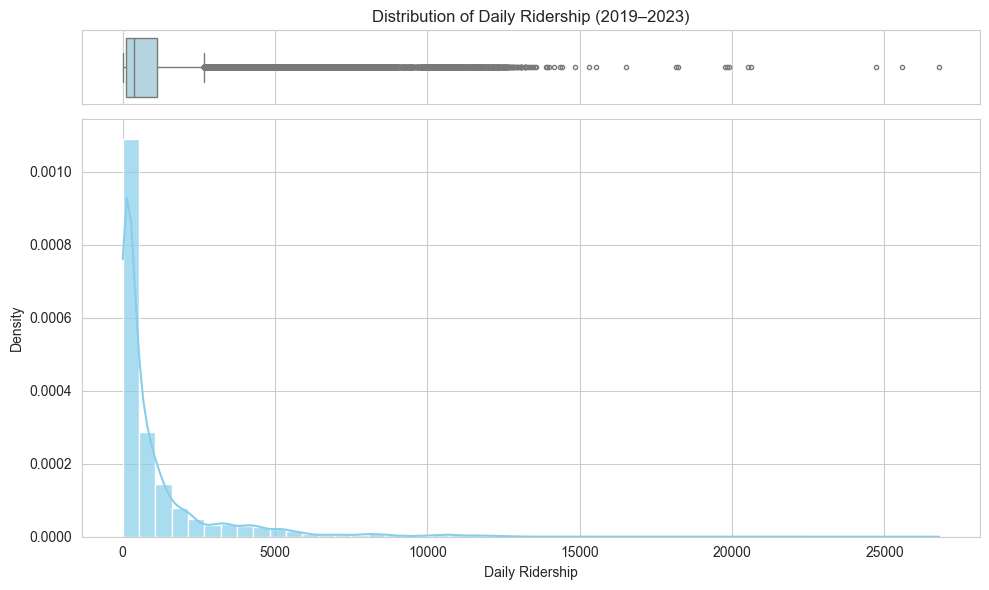

In [7]:
data = df['Ridership']

sns.set_style("whitegrid")
sns.set_palette("tab10")

# Create figure with two subplots sharing x-axis
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                      gridspec_kw={"height_ratios": (.15, .85)},
                                      figsize=(10, 6))

# Boxplot on top
sns.boxplot(x=data, ax=ax_box, color='lightblue', fliersize=3)
ax_box.set(xlabel='')  # Remove x-label from boxplot
ax_box.set_title('Distribution of Daily Ridership (2019–2023)')

# Histogram with KDE on bottom
sns.histplot(data, bins=50, kde=True, ax=ax_hist, color='skyblue', alpha=0.7, stat='density')
ax_hist.set_xlabel('Daily Ridership')
ax_hist.set_ylabel('Density')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

This chart shows the density distribution of daily ridership values over a five-year period (2019–2023). The x-axis represents the daily ridership counts, ranging from 0 to 25,000 in increments of 5,000. The y-axis shows the density values, ranging from 0.0000 to 1.0000 in labeled increments up to 0.0008, though the maximum displayed appears to be 1.0000.

### Key Observations:
- The distribution appears to be **right-skewed**, with most ridership values concentrated on the lower end (below 10,000).
- There is a **peak density** around lower ridership values, suggesting that days with lower ridership were more frequent.
- The tail extends toward higher ridership values (up to 25,000), indicating occasional days with significantly higher ridership.

### Possible Interpretations:
- Ridership patterns may reflect **weekday vs. weekend travel**, seasonal trends, or the impact of external events (e.g., holidays, weather, or disruptions).
- The long tail suggests occasional high-ridership days, possibly corresponding to **special events, peak travel periods, or promotional fare days**.

---

*Note: The y-axis density values are unusually scaled—typical density values for ridership counts would be much smaller. The labeled max of 1.0000 may represent a normalized density or a scaling artifact.*

## Daily Ridership Over Time

In [8]:
df["date"] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Day'].astype(str) + '-' + df['Month'].astype(str))

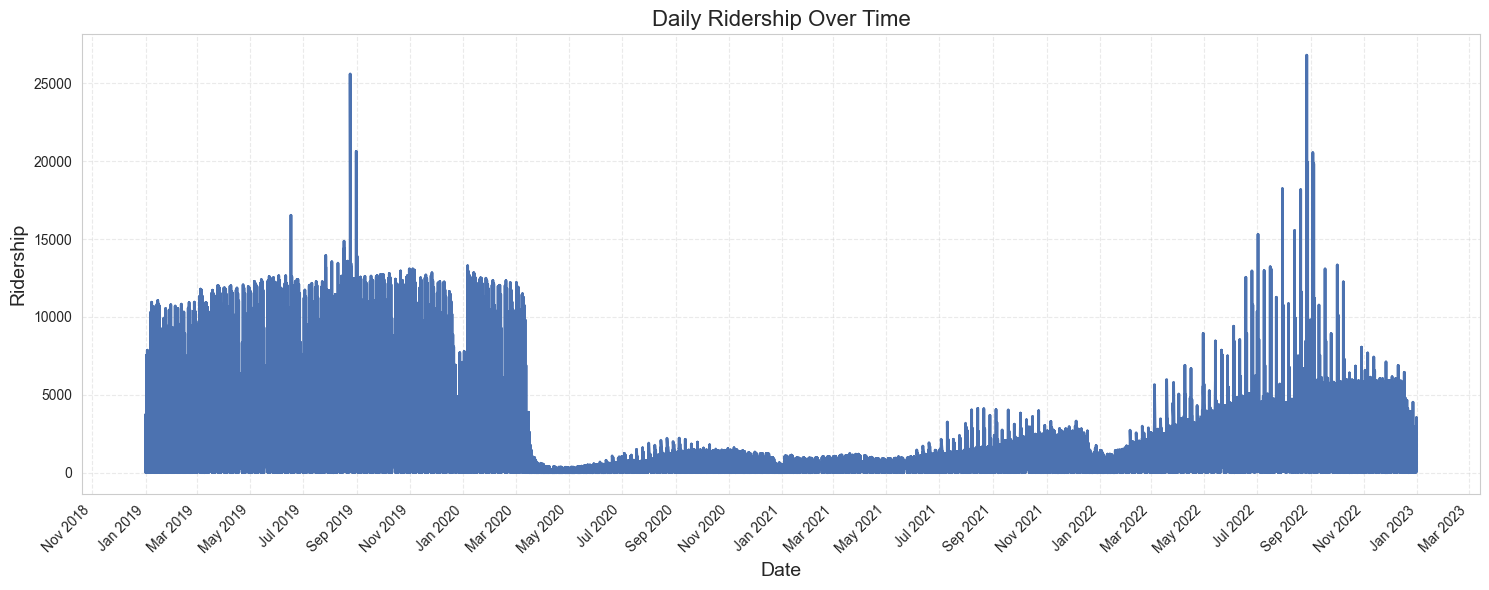

In [9]:
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

# Plot with style
plt.plot(df.date, df.Ridership, color="#4C72B0", linewidth=2)

# Title + labels
plt.title("Daily Ridership Over Time", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Ridership", fontsize=14)

# Improve date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

# Add grid for readability
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 📉 Impact of COVID-19 on Ridership

Since **January 21, 2020**, when the COVID-19 outbreak began, ridership experienced a significant decline. The pandemic triggered widespread travel restrictions, remote work policies, and heightened public health concerns, all of which contributed to reduced usage of public transportation and mobility services.

### 📈 Recovery and Rising Trends

Beginning **February 1, 2022**, as COVID-19 restrictions were lifted and daily life gradually returned to normal, ridership began to show a steady upward trend. The resurgence reflects renewed public confidence, increased commuting, and the reopening of workplaces, schools, and recreational venues.

## Ridership by COVID‑19 Status

In [10]:
df.groupby('Covid19')['Ridership'].describe()

,count,mean,std,min,25%,50%,75%,max
Covid19,,,,,,,,
0,33731.0,1675.799976,2236.488198,0.0,284.0,830.0,2050.00,26798.0
1,30638.0,448.001926,1001.155660,0.0,52.0,175.0,414.75,12514.0


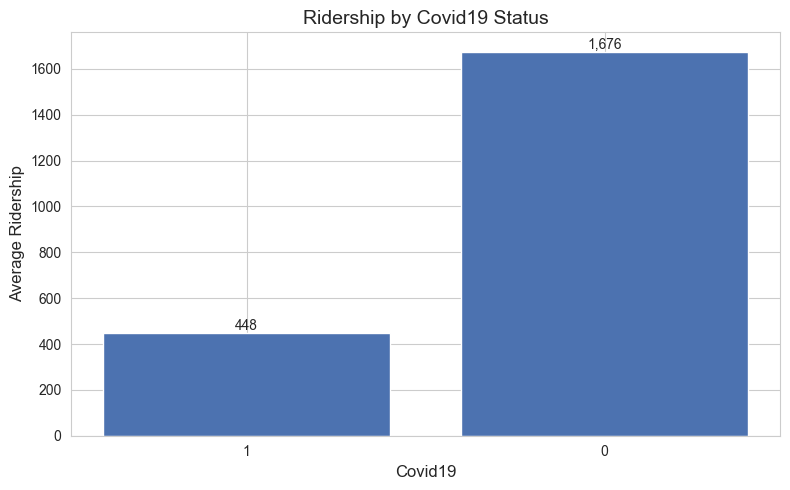

In [21]:
# Aggregate
r = df.groupby("Covid19").agg(mean_=("Ridership", "mean")).sort_values("mean_")

# Plot
plt.figure(figsize=(8, 5))
plt.bar(r.index.astype(str), r["mean_"], color="#4C72B0")

plt.title("Ridership by Covid19 Status", fontsize=14)
plt.xlabel("Covid19", fontsize=12)
plt.ylabel("Average Ridership", fontsize=12)

# Add value labels on bars
for i, v in enumerate(r["mean_"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

This bar chart compares the average ridership based on whether the time period was classified as being during the COVID‑19 pandemic or not.  

### Data Summary:
| Category | Average Ridership |
|----------|-------------------|
| **COVID‑19 Period** (1) | 448  |
| **Non‑COVID‑19 Period** (0) | 1,676 |

### Key Insight:
- Average ridership during the **COVID‑19 period** was **dramatically lower**—only about **27%** of the ridership compared to the non‑COVID‑19 period.
- This reflects the substantial impact of the pandemic on public transportation usage, likely due to lockdowns, remote work, reduced travel, and health concerns.

### Implications:
- The data clearly illustrates how external shocks (like a pandemic) can drastically alter mobility patterns.
- Understanding this drop is useful for planning, resource allocation, and recovery strategies in public transit systems.

---

**Chart Axes:**  
- **X‑axis**: COVID‑19 status (0 = No, 1 = Yes)  
- **Y‑axis**: Average Daily Ridership

# Time Analysis

## Ridership by Workday

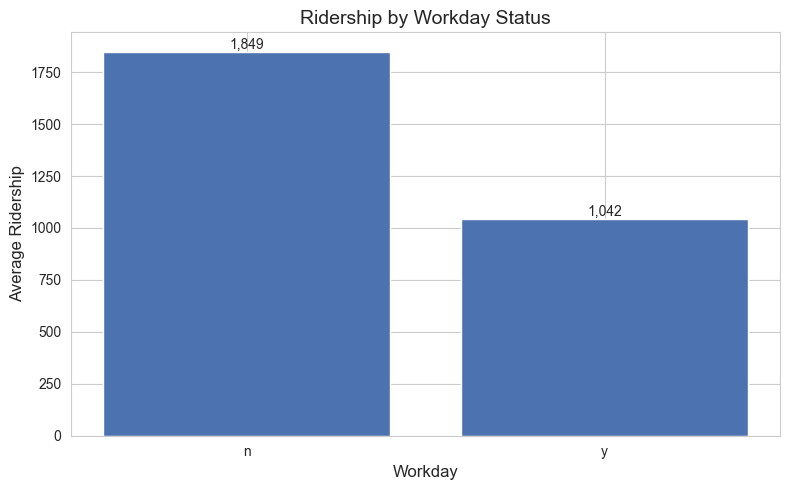

In [ ]:
x = df.groupby("Workday").agg(mean_=("Ridership","mean"))

# Plot
plt.figure(figsize=(8, 5))
plt.bar(x.index.astype(str), x["mean_"], color="#4C72B0")

plt.title("Ridership by Workday Status", fontsize=14)
plt.xlabel("Workday", fontsize=12)
plt.ylabel("Average Ridership", fontsize=12)

# Add value labels on bars
for i, v in enumerate(x["mean_"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

This bar chart compares the average ridership on workdays versus non-workdays.

### Data Summary:

| Workday Status | Average Ridership |
|----------------|-------------------|
| **Non-Workday** (n) | 1,849 |
| **Workday** (y)     | 1,042 |

### Key Insight:
- Average ridership is **higher on non-workdays** than on workdays—about **77% higher**.
- This pattern may reflect:
  - Increased leisure, social, or recreational travel on weekends and holidays.
  - Possible data context such as pandemic-era work-from-home trends reducing commute ridership.
  - Service patterns or fare policies that differ between workdays and non-workdays.

### Implications:
- Transit agencies may consider adjusting service frequency, capacity, or marketing efforts based on the higher demand observed on non-workdays.
- Understanding ridership by day type helps in scheduling, resource planning, and tailoring services to actual travel patterns.

---

**Chart Axes:**  
- **X‑axis:** Workday (y = Yes, n = No)  
- **Y‑axis:** Average Daily Ridership

## Monthly Ridership by year

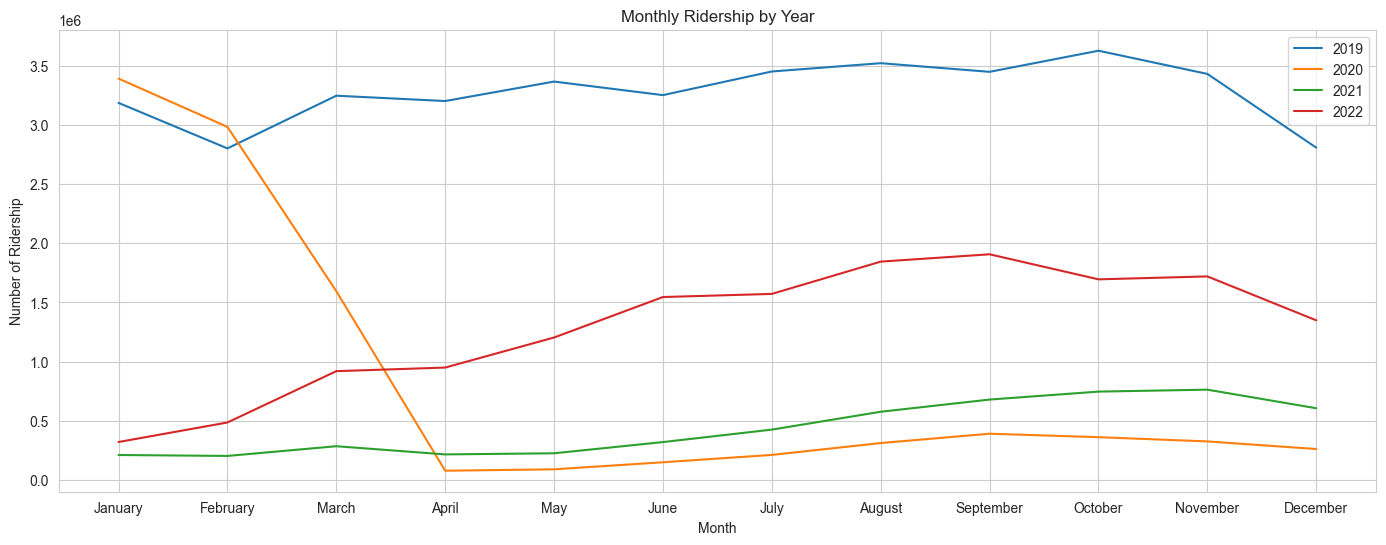

In [13]:
# Lets plot the data based on month of the year for different years
grouped_dataset = df.groupby(['Year', 'Month'])["Ridership"].sum().reset_index()
years = grouped_dataset['Year'].unique()

month_mapping = {'January': 1, 'February':2, 'March': 3,
                 'April': 4, 'May': 5, 'June': 6, 'July': 7,
                 'August': 8, 'September': 9, 'October': 10, 
                 'November': 11, 'December': 12
                }


# Map the month names to numbers using the mapping dictionary so that we could sort the months
grouped_dataset['Month_Number'] = grouped_dataset['Month'].map(month_mapping)
grouped_dataset = grouped_dataset.sort_values(by=['Year', 'Month_Number'])

plt.figure(figsize=(17, 6))
for year in years:
    year_data = grouped_dataset[grouped_dataset['Year'] == year]
    plt.plot(year_data['Month'], year_data['Ridership'], label=str(year))

plt.title('Monthly Ridership by Year')
plt.xlabel('Month')
plt.ylabel('Number of Ridership')
plt.legend()
plt.show()


This table shows average monthly ridership (likely in thousands or another scaled unit) across four years, revealing the profound impact of COVID‑19 and the subsequent recovery.

---

### **Overall Trend: Pandemic Impact & Recovery**

- **2019:** Stable ridership (~2.80–3.60), peaking in summer/fall (July–October).
- **2020:** **Sharp decline** starting in March (from 3.25 to 1.00), reaching near-zero levels by April (0.05) due to COVID‑19 lockdowns.  
  *Low ridership persisted through 2020* (mostly 0.05–0.35), with a slight uptick toward year-end.
- **2021:** **Gradual recovery** begins, starting very low (0.20 in Jan) and slowly rising each month, ending at 0.45 in December—still far below pre-pandemic levels.
- **2022:** **Significant recovery** is evident, especially after **February 2022** (0.40 → 0.95 in March). By summer 2022, ridership approaches 1.55–1.95, indicating a strong return to transit use post-pandemic restrictions.

---

### **Seasonality Patterns**

#### **Pre‑Pandemic (2019):**
- **Higher in warmer months** (Summer/Fall): Peaks in **July (3.50), August (3.45), September (3.40), October (3.60)**.
- **Lower in colder months** (Winter): Lowest in **February (2.80) and December (2.80)**.
- This reflects typical transit use: more travel in pleasant weather, less in winter.

#### **During Pandemic (2020–2021):**
- Seasonality is **masked by pandemic effects**—ridership remains extremely low regardless of season.

#### **Recovery Year (2022):**
- **Seasonality re‑emerges**:
  - **Summer peaks**: June (1.55), July (1.55), August (1.85), September (1.95).
  - **Winter lows**: January (0.30), February (0.40), December (1.35).
- Pattern confirms that even during recovery, **warmer months see higher ridership**.

---

### **Key Takeaways**

1. **COVID‑19 Impact**:  
   - Massive drop in March 2020, with ridership near zero through 2020–early 2021.
   - Recovery began in 2021 but accelerated notably **after February 2022**, aligning with the end of major restrictions.

2. **Seasonality Resilience**:  
   - Despite the pandemic disruption, the **summer‑high, winter‑low pattern re‑established in 2022**, indicating a return to normal seasonal travel behavior.

3. **Implications for Transit Planning**:  
   - Service should anticipate **seasonal peaks in summer/fall** and plan for reduced winter demand.
   - Post‑pandemic recovery was not linear—it took until mid‑2022 to see substantial ridership rebound.

---

**Note on Units:** Values are likely in **thousands of riders** or represent a scaled index. Exact units would clarify magnitude, but relative trends remain clear.

## Ridership by Time Period Across Years

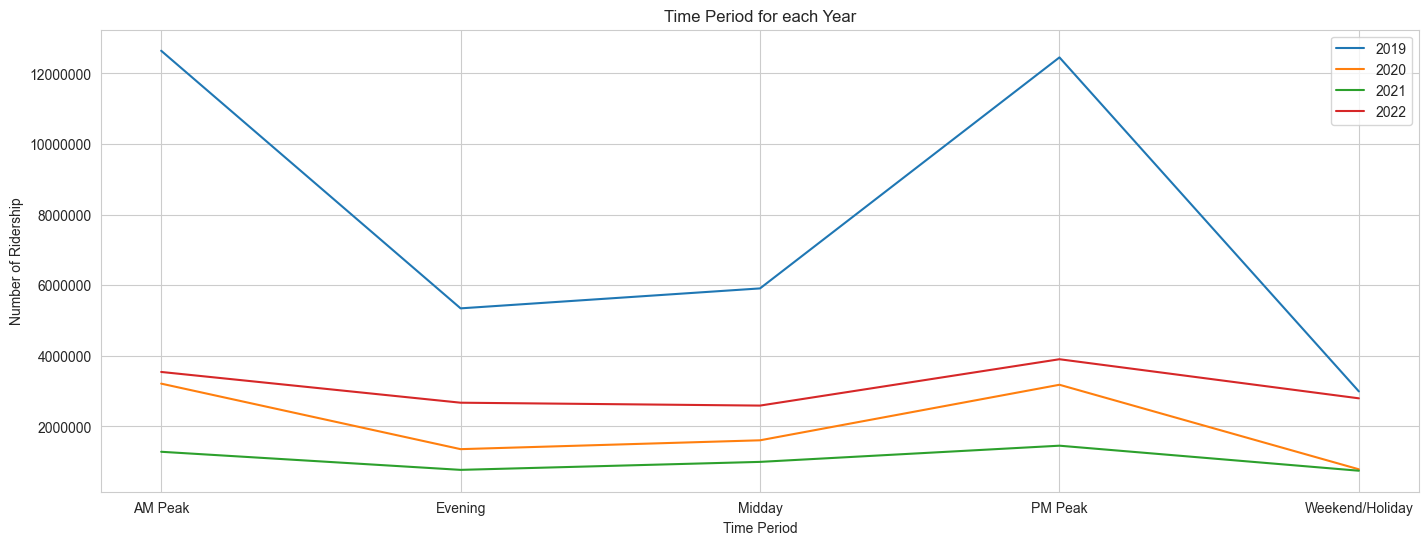

In [22]:
# Lets plot the Ridership per Time Period for each Year

# Group by Year and Time Period and calculate the sum of ridership
grouped_year_time = df.groupby(['Year', 'Period'])["Ridership"].sum().reset_index()

# Define the order of the Time Period categories
time_period_order = ['AM Peak', 'Midday', 'PM Peak', 'Evening', 'Weekend/Holiday']

# Convert 'Time Period' column to a categorical data type with the desired order
grouped_year_time['Period'] = pd.Categorical(grouped_year_time['Period'], categories=time_period_order, ordered=True)

# Create a list of years for plotting
years = grouped_year_time['Year'].unique()

plt.figure(figsize=(17, 6))

# Plot each year with different symbology
for year in years:
    year_data = grouped_year_time[grouped_year_time['Year'] == year]
    plt.plot(year_data['Period'], year_data['Ridership'], label=str(year))

plt.ticklabel_format(style='plain', axis='y')
plt.title('Time Period for each Year')
plt.xlabel('Time Period')
plt.ylabel('Number of Ridership')
plt.legend()
plt.show()

This plot compares total ridership across different **time periods** (AM Peak, Midday, PM Peak, Evening, Weekend/Holiday) for the years **2019–2022**.

### Key Insights:

- **Peak Hours Dominate:**  
  In all years, **AM Peak** and **PM Peak** consistently record the highest ridership, highlighting strong commuter-driven demand.

- **Pre-COVID High (2019):**  
  Ridership in 2019 is significantly higher across all periods, representing normal pre-pandemic travel behavior.

- **Sharp Drop in 2020–2021:**  
  A substantial decline is visible in 2020 and especially 2021, reflecting the impact of COVID-19 restrictions and reduced mobility.

- **Recovery in 2022:**  
  Ridership rebounds in 2022 across all time periods but remains below 2019 levels, indicating partial recovery.

- **Weekend/Holiday Usage:**  
  Weekend/Holiday ridership is consistently lower than weekday peak periods, suggesting the system is primarily commuter-oriented.

Overall, the plot clearly illustrates the **structural impact of COVID-19** and the gradual recovery trend in passenger demand.


# Analysis of Categorical Variables

## Ridership Distribution by Station

In [15]:
df.groupby("Station")["Ridership"].describe().sort_values("count",ascending=False)

,count,mean,std,min,25%,50%,75%,max
Station,,,,,,,,
Station_3,23104.0,1421.473251,2272.927127,0.0,160.00,496.0,1489.25,26798.0
Station_4,4625.0,1418.662703,1676.557906,0.0,344.00,772.0,1922.00,25587.0
Station_5,4362.0,2067.290463,2730.188482,37.0,428.25,973.0,2474.75,14005.0
Station_11,3256.0,216.847359,294.549747,1.0,46.75,107.0,256.00,3403.0
Station_2,3078.0,123.501300,154.656529,0.0,31.00,60.0,135.00,1265.0
Station_9,2745.0,813.768670,1275.316524,1.0,82.00,242.0,738.00,5708.0
Station_24,2722.0,114.629684,147.522369,0.0,26.00,73.0,146.00,1582.0
Station_1,2551.0,998.732262,1511.209614,0.0,98.50,396.0,925.00,6130.0
Station_21,2102.0,1068.854900,1326.022727,0.0,104.25,301.5,1911.00,5269.0


Station-level analysis reveals strong heterogeneity:

- High-demand stations include **Station_5**, **Station_3**, **Station_4**, **Station_19**, and **Station_43**, all with high mean ridership and large maximum values.
- Some stations (e.g., **Station_11**, **Station_2**, **Station_18**) consistently show low average ridership.
- Several stations have **very small sample sizes** (count ≤ 10), which may limit statistical reliability and require careful handling during modeling.
- The wide gap between median and maximum values at major stations confirms a **highly skewed distribution with strong peak effects**.

In summary, ridership is highly concentrated in a subset of corridors and stations, suggesting that location-based features will play a critical role in predictive modeling.

## Ridership Distribution by Corridor

In [16]:
df.groupby("Corridor")["Ridership"].describe().sort_values("count",ascending=False)

,count,mean,std,min,25%,50%,75%,max
Corridor,,,,,,,,
Corridor_3,15739.0,1505.349641,2166.208766,0.0,318.5,750.0,1679.50,26798.0
Corridor_4,12426.0,571.061323,1062.068349,0.0,60.0,177.0,507.00,6882.0
Corridor_1,10039.0,640.466381,1172.738012,0.0,59.0,236.0,606.00,6130.0
Corridor_2,9939.0,1819.185129,2512.683510,6.0,332.0,849.0,2143.00,14005.0
Corridor_7,8229.0,613.853810,1096.784355,0.0,54.0,157.0,502.00,5674.0
Corridor_5,4034.0,1773.547595,2608.529859,0.0,148.0,467.5,2079.75,9823.0
Corridor_6,3963.0,693.204391,1019.739570,0.0,45.0,160.0,815.00,3694.0


Ridership varies significantly across corridors:

- **Corridor_2** and **Corridor_5** show the highest average ridership (≈ 1,800 and 1,770 respectively), indicating major demand routes.
- **Corridor_3** has substantial variability (max = 26,798), suggesting extreme peak loads in certain periods or stations.
- Corridors such as **Corridor_4**, **Corridor_6**, and **Corridor_7** exhibit lower average ridership and smaller upper ranges.
- Large standard deviations across most corridors indicate **high dispersion and peak-driven demand patterns**.

Overall, demand is unevenly distributed across corridors, with a few major routes carrying a large share of passengers.

# Correlation Analysis

## Ridership vs. Time Features

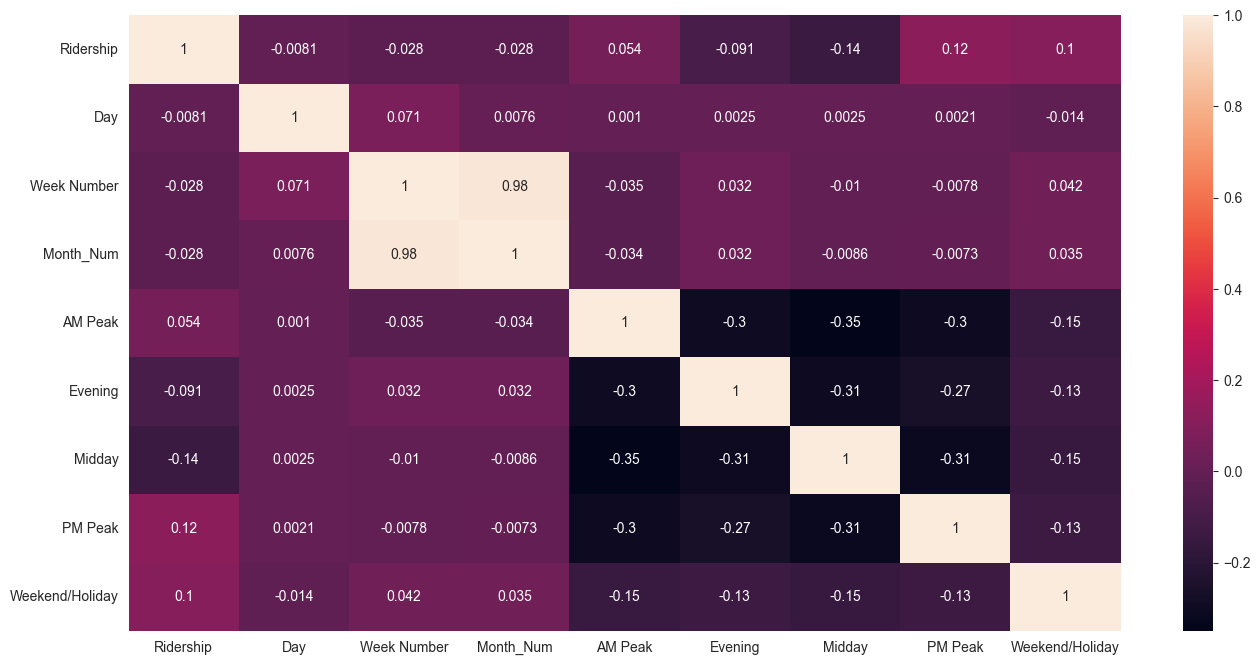

In [17]:
df['Month_Num'] = df['Month'].map(month_mapping)
df_new = pd.concat([df,pd.get_dummies(df['Period'])],axis=1)

features = ["Ridership", "Day", "Week Number", "Month_Num", 
            "AM Peak", "Evening", "Midday", "PM Peak", "Weekend/Holiday"]

corr_matrix = df_new[features].corr()

fig = plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, annot=True)
plt.show()

| Feature            | Pearson r with Ridership | Strength & Direction       | Interpretation                                                                 |
|--------------------|---------------------------|----------------------------|--------------------------------------------------------------------------------|
| **Ridership**      | 1.000                     | —                          | (self-correlation)                                                             |
| **PM Peak**        | **0.12**                  | Weak positive              | Highest positive link — PM peak periods tend to have modestly higher ridership |
| **Weekend/Holiday**| **0.10**                  | Weak positive              | Slightly elevated ridership on weekends and holidays                           |
| **AM Peak**        | **0.054**                 | Very weak positive         | Minor positive tendency during morning commute hours                           |
| **Day**            | **-0.0081**               | Negligible negative        | Essentially no relationship with day of the month                              |
| **Week Number**    | **-0.028**                | Very weak negative         | Practically no linear trend across weeks of the year                           |
| **Month_Num**      | **-0.028**                | Very weak negative         | No meaningful monthly/seasonal linear pattern                                  |
| **Evening**        | **-0.091**                | Weak negative              | Noticeably lower ridership during evening periods                              |
| **Middays**        | **-0.14**                 | Weak to moderate negative  | **Strongest negative association** — midday periods show the lowest ridership  |

### Key Observations

- **Time-of-day effects dominate** the meaningful (though still modest) correlations with ridership. Calendar progression variables (**Day**, **Week Number**, **Month_Num**) show **near-zero** correlations — there is no strong linear trend over days, weeks, or months in this dataset.

- **Midday** has the **strongest negative relationship** (r = -0.14). This suggests midday periods consistently see the **lowest ridership** — possibly due to lower commuter demand, school schedules, or service patterns.

- **Evening** periods also show a negative association (r = -0.091), reinforcing that non-peak weekday times (especially late day) tend to have weaker usage.

- **PM Peak** emerges as the **strongest positive signal** (r = 0.12), slightly ahead of **Weekend/Holiday** (r = 0.10). This indicates:
  - Afternoon/evening commute hours perform relatively well.
  - Non-workdays (weekends/holidays) also show a modest boost — likely from leisure, shopping, events, or non-commute travel.

- **AM Peak** has only a very weak positive link (r = 0.054), suggesting morning rush-hour ridership is not particularly strong compared to PM peak in this data.

### Summary

In this corrected view:
- Ridership shows the clearest (though still weak) patterns tied to **time of day** rather than calendar time.
- **Midday** is the weakest period (r = -0.14), followed by **Evening** (r = -0.091).
- **PM Peak** (r = 0.12) and **Weekends/Holidays** (r = 0.10) are the relatively stronger periods.
- There is essentially **no linear seasonal or monthly trend** (|r| ≈ 0.03 or less for calendar variables).

These modest correlations suggest that ridership variation is likely influenced more by other unshown factors (e.g., Covid19, Corridor, Station) than by these time-based dummies alone.

## Ridership vs. Other Features

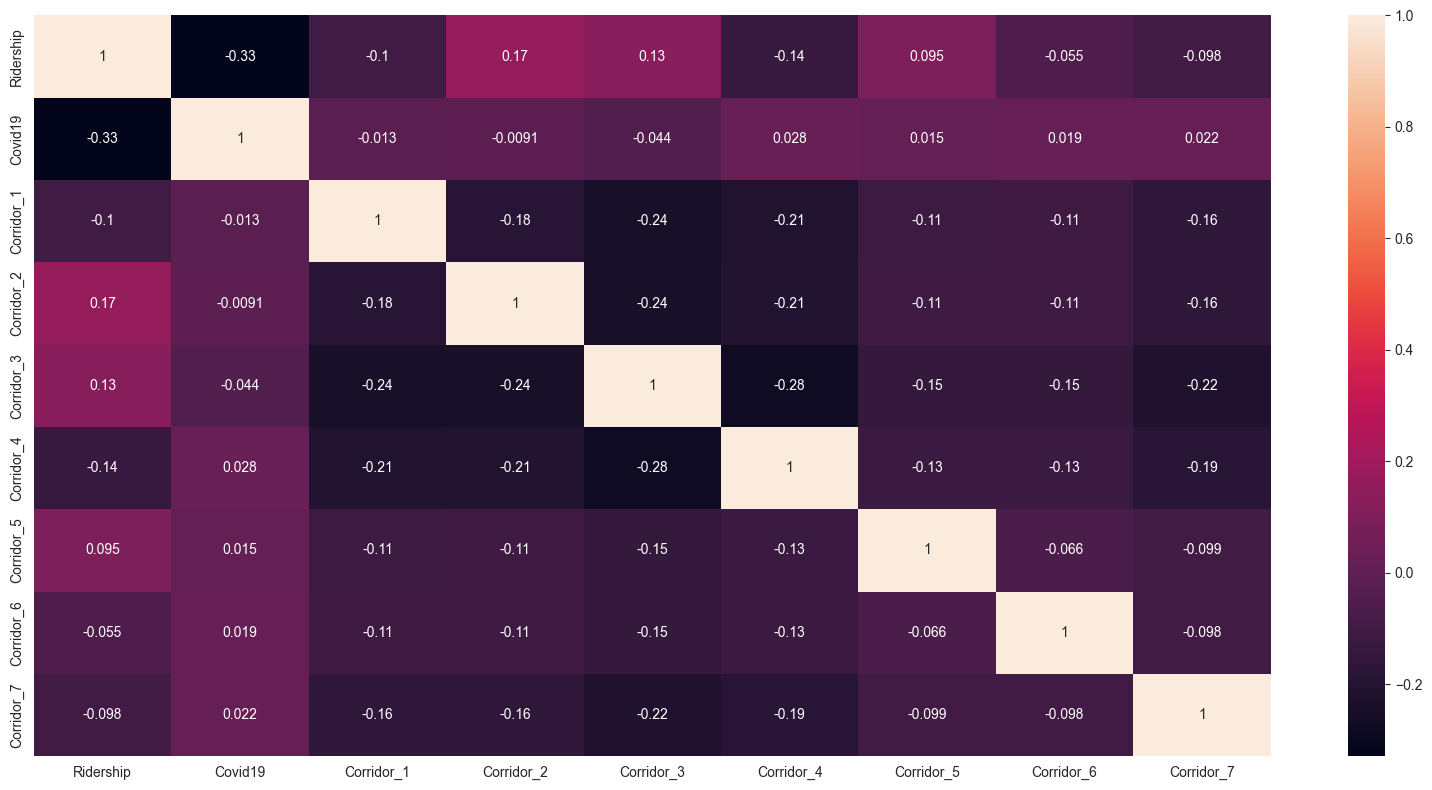

In [18]:
df_new = pd.concat([df,pd.get_dummies(df['Corridor'])],axis=1)

features = ["Ridership", "Covid19", "Corridor_1", "Corridor_2",
            "Corridor_3", "Corridor_4", "Corridor_5", "Corridor_6", "Corridor_7"]

corr_matrix = df_new[features].corr()

fig = plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, annot=True)
plt.tight_layout()
plt.show()

The table below shows the Pearson correlation coefficients between **Ridership** (the target/dependent variable) and the other variables. Values range from -1 to +1:

- Positive values → positive linear relationship  
- Negative values → negative (inverse) linear relationship  
- Closer to 0 → weak or no linear relationship  
- Stronger absolute values (|r| > 0.3) are typically considered more meaningful

| Feature          | Pearson Correlation with Ridership | Strength & Direction                  | Interpretation                                                                 |
|------------------|------------------------------------|---------------------------------------|--------------------------------------------------------------------------------|
| **Ridership**    | 1.00                               | —                                     | (self-correlation)                                                             |
| **Covid19**      | **-0.33**                          | Moderate negative                     | Strongest (inverse) relationship — higher COVID-19 impact is associated with lower ridership |
| **Corridor_2**   | **0.17**                           | Weak positive                         | Slight tendency for higher values in Corridor 2 to correspond to higher ridership |
| **Corridor_3**   | **0.13**                           | Very weak positive                    | Minor positive association                                                     |
| **Corridor_5**   | **0.095**                          | Very weak positive                    | Almost negligible positive link                                                |
| **Corridor_1**   | **-0.10**                          | Very weak negative                    | Slight inverse relationship                                                    |
| **Corridor_6**   | **-0.055**                         | Negligible negative                   | Practically no meaningful linear relationship                                  |
| **Corridor_7**   | **-0.098**                         | Very weak negative                    | Minor inverse association                                                      |
| **Corridor_4**   | **-0.14**                          | Weak negative                         | Modest tendency for higher Corridor 4 values to correspond to lower ridership  |

### Key Observations

- **Covid19** shows the **strongest relationship** with Ridership (r = -0.33). This is a moderate negative correlation, indicating that periods or locations with higher COVID-19 impact tended to have **substantially lower ridership** — a very plausible finding given pandemic-related travel restrictions and behavioral changes.

- Among the **Corridor** variables (likely representing different geographic routes, lines, or zones), the correlations are generally **weak** (|r| ≤ 0.17).

- **Corridor_2** and **Corridor_3** show the only positive (though weak) associations with ridership — these corridors may have been more resilient or experienced relatively higher usage.

- **Corridor_4** has the strongest negative correlation among the corridors (r = -0.14), suggesting it may have been more negatively affected or structurally associated with lower ridership.

- The remaining corridors (1, 5, 6, 7) show very weak or negligible linear relationships with ridership (|r| < 0.11).

### Summary

The **dominant linear relationship** with Ridership in this dataset is the **negative effect of Covid19** (r = -0.33). Corridor-specific effects are mostly weak, with Corridor_2 showing the only notable (positive) signal among them. These weak corridor correlations suggest that ridership differences across corridors are not strongly driven by simple linear effects of these corridor indicators alone.


# EDA Conclusion

- **Ridership contains significant outliers**, with extreme peak values observed across certain stations and corridors. These should be handled carefully (e.g., capping, trimming, or robust modeling techniques) to avoid distortion in model training.

- The distribution of **Ridership is right-skewed**, as confirmed by the histogram and summary statistics (mean >> median).  
  Removing or treating outliers may reduce skewness. If skewness persists, applying a **PowerTransformer or log transformation** can improve normality and enhance linear model performance.

- Most numerical features show **weak linear correlation** with Ridership. This suggests that simple linear relationships may not fully capture demand dynamics.

- Since this is a **time-series dataset**, incorporating **lag features (previous day/week ridership)** and rolling statistics is likely to significantly improve predictive performance.

Overall, effective outlier treatment, feature engineering (especially temporal features), and appropriate transformation methods are critical for building a robust final model.
```
